DATA VIZ

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import torch

DATASET_BASES = {
    "original": "./chest_xray/chest_xray",
    "cleaned": "./chest_xray_cleaned",
}
BASE = DATASET_BASES["original"]  # Backward-compatible default for the original single-run cells.
classes = ["NORMAL", "PNEUMONIA"]
SOURCE_SPLITS = ["train", "val", "test"]   # Kaggle's original splits — we merge all 3 and re-split 80/10/10
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
SEED = 42
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CHANNELS = 1
NUM_EPOCHS = 15

# Seed every RNG source so splits, sampling and training are
# reproducible across machines (Python random, NumPy, PyTorch CPU + CUDA)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)



**Experiment Utility Imports**

The dataclasses live in `scripts/experiment_types.py`; the notebook instantiates them from the shared constants so hyperparameters remain defined in one place.


In [2]:
from scripts.experiment_types import DataBundle, DatasetRunConfig, ExperimentResult, TrainingConfig

RUN_CONFIGS = {
    name: DatasetRunConfig(
        name=name,
        base_dir=base_dir,
        classes=tuple(classes),
        source_splits=tuple(SOURCE_SPLITS),
        image_exts=tuple(IMAGE_EXTS),
        seed=SEED,
    )
    for name, base_dir in DATASET_BASES.items()
}
LOCKED_TRAINING = TrainingConfig(
    img_size=IMG_SIZE,
    num_channels=NUM_CHANNELS,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    dropout=0.4,
    weight_decay=0.0,
)


def set_all_seeds(seed: int = SEED):
    """Reset every RNG used by the notebook before creating a fresh model/run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def build_splits_from_config(config: DatasetRunConfig):
    """Create deterministic 80/10/10 splits from one dataset's relative image paths."""
    rng = random.Random(config.seed)
    all_files = {}

    for cls in config.classes:
        relative_paths = []
        for split in config.source_splits:
            cls_dir = os.path.join(config.base_dir, split, cls)
            for f in sorted(os.listdir(cls_dir)):
                if os.path.splitext(f)[1].lower() in config.image_exts:
                    relative_paths.append(os.path.join(split, cls, f))
        rng.shuffle(relative_paths)
        all_files[cls] = relative_paths

    split_data = {"train": {}, "val": {}, "test": {}}
    for cls, files in all_files.items():
        n = len(files)
        n_train = int(n * 0.8)
        n_val = int(n * 0.1)
        split_data["train"][cls] = files[:n_train]
        split_data["val"][cls] = files[n_train:n_train + n_val]
        split_data["test"][cls] = files[n_train + n_val:]

    return split_data


def missing_split_files(base_dir: str, split_data: dict[str, dict[str, list[str]]]):
    """Check whether a dataset variant can reuse a shared split without leakage or drift."""
    missing = []
    for split in split_data.values():
        for files in split.values():
            for relative_path in files:
                if not os.path.exists(os.path.join(base_dir, relative_path)):
                    missing.append(relative_path)
    return missing


In [3]:
# Build one shared split from the original dataset and reuse its relative paths for both runs.
# This keeps train/val/test membership identical between original and cleaned images.
splits_data = build_splits_from_config(RUN_CONFIGS["original"])

missing_by_dataset = {
    name: missing_split_files(config.base_dir, splits_data)
    for name, config in RUN_CONFIGS.items()
}
missing_by_dataset = {name: missing for name, missing in missing_by_dataset.items() if missing}
if missing_by_dataset:
    raise FileNotFoundError(f"Dataset variants do not contain the same split files: {missing_by_dataset}")


In [4]:
def summarize_splits(splits_data):
    print("\nDataset Summary")

    total = 0

    for split_name, split in splits_data.items():
        print(f"\n{split_name.upper()}:")

        split_total = 0

        for cls, files in split.items():
            count = len(files)
            split_total += count
            print(f"  {cls}: {count}")

        total += split_total
        print(f"  ➜ Total: {split_total}")

    print(f"\nOverall total images: {total}")


summarize_splits(splits_data)


Dataset Summary

TRAIN:
  NORMAL: 1266
  PNEUMONIA: 3418
  ➜ Total: 4684

VAL:
  NORMAL: 158
  PNEUMONIA: 427
  ➜ Total: 585

TEST:
  NORMAL: 159
  PNEUMONIA: 428
  ➜ Total: 587

Overall total images: 5856


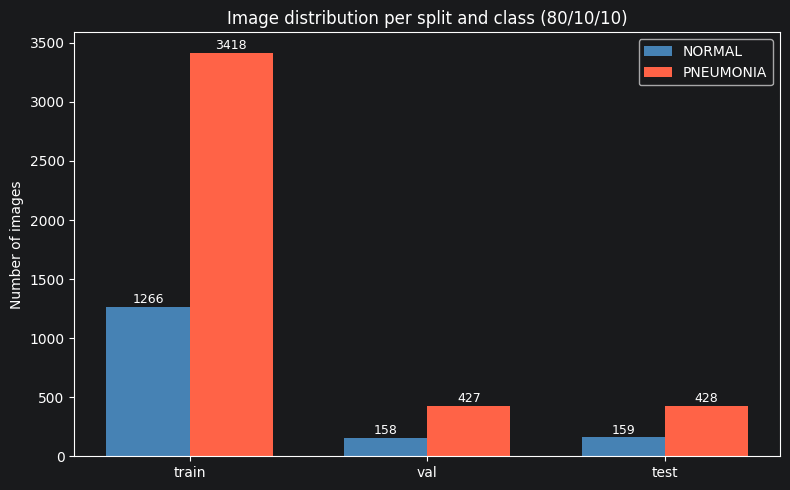

In [5]:
splits = ["train", "val", "test"]
counts = {split: {cls: len(splits_data[split][cls]) for cls in classes} for split in splits}

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [counts[s]["NORMAL"]    for s in splits], width, label="NORMAL",    color="steelblue")
bars2 = ax.bar(x + width/2, [counts[s]["PNEUMONIA"] for s in splits], width, label="PNEUMONIA", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of images")
ax.set_title("Image distribution per split and class (80/10/10)")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Show some lungs :)

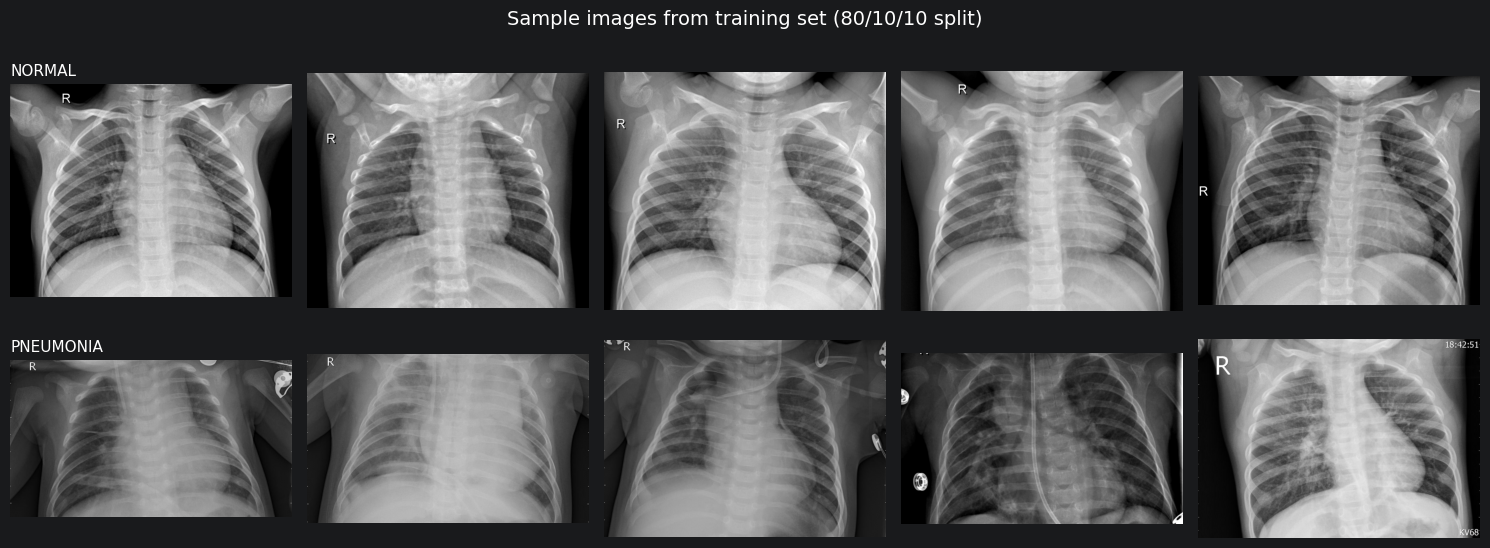

In [6]:
# Show sample images from the training split
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample images from training set (80/10/10 split)", fontsize=14)

for row, cls in enumerate(classes):  # 0 = NORMAL, 1 = PNEUMONIA
    files = splits_data["train"][cls][:5]
    for col, relative_path in enumerate(files):  # relative_path: "train/NORMAL/IM-0001.jpeg"
        img = mpimg.imread(os.path.join(BASE, relative_path))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, loc="left")

plt.tight_layout()
plt.show()

Show class distribution

In [7]:
# Total count per class across train/val/test
class_totals = {}

for cls in classes:
    total = 0

    for split in splits:
        total += counts[split][cls]

    class_totals[cls] = total
class_totals

{'NORMAL': 1583, 'PNEUMONIA': 4273}

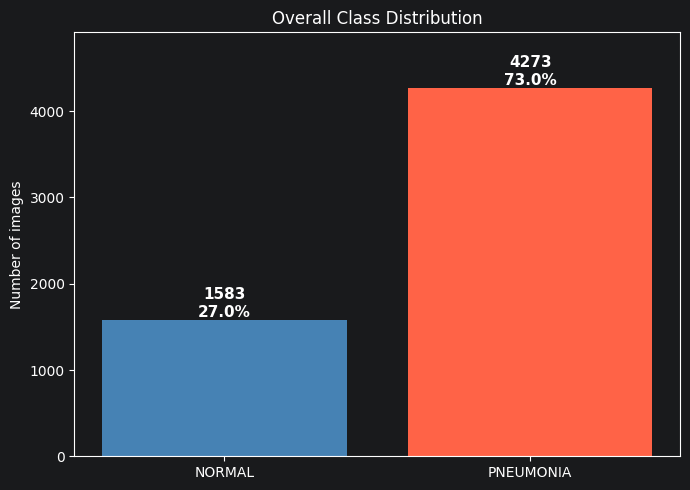

Class distribution:
NORMAL: 1583 images (27.0%)
PNEUMONIA: 4273 images (73.0%)


In [8]:
total_images = sum(class_totals.values())

class_names = ["NORMAL", "PNEUMONIA"]
values = [class_totals[key] for key in class_names]
percentages = [(value / total_images) * 100 for value in values]

colors = ["steelblue", "tomato"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(class_names, values, color=colors)

ax.set_title("Overall Class Distribution")
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(values) * 1.15)

# Add count and percentage labels above bars
for bar, count, pct in zip(bars, values, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("Class distribution:")
for name, count, pct in zip(class_names, values, percentages):
    print(f"{name}: {count} images ({pct:.1f}%)")

There's a clear class imbalance here, we need to handle this

**Preprocessing**

Keep images to the 224x224 standard

In [9]:
import os
import torch
from PIL import Image, ImageOps
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt


print(f"Using fixed resize target: {IMG_SIZE}x{IMG_SIZE}px")

# Detect hardware: CUDA (NVIDIA GPUs), MPS (Apple Silicon M1/M2/M3), or CPU fallback
import platform

if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"Using device: CUDA — {device_name}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon — {platform.processor() or platform.machine()})")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU ({platform.processor() or platform.machine()})")

print(f"PyTorch version: {torch.__version__}")
print(f"Platform: {platform.system()} {platform.release()}")

class PadToSquare: #Example 1000x500 turns to 1000 x 1000 px, prevents stretching before resizing
    def __init__(self, fill=0):
        self.fill = fill

    def __call__(self, image):
        width, height = image.size

        if width == height:
            return image

        max_side = max(width, height)

        padding_left = (max_side - width) // 2
        padding_right = max_side - width - padding_left
        padding_top = (max_side - height) // 2
        padding_bottom = max_side - height - padding_top

        padding = (
            padding_left,
            padding_top,
            padding_right,
            padding_bottom
        )

        return ImageOps.expand(image, padding, fill=self.fill)

Using fixed resize target: 224x224px
Using device: CUDA — NVIDIA GeForce RTX 5070 Laptop GPU
PyTorch version: 2.11.0+cu128
Platform: Windows 10


In [10]:
train_transform = transforms.Compose([ #Input example: Blue x-ray 1200 x 800 px
    transforms.Grayscale(num_output_channels=NUM_CHANNELS), # gray-scaled x-ray 1200 x 800
    PadToSquare(fill=0), # 1200x1200 (black bars added)
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #resized to 224x224

    # Light augmentation only
    transforms.RandomAffine(
        degrees=7, # rotate between -7 and - 7 degrees
        translate=(0.03, 0.03), # Moves the img horizontally or vertically up to 3% of the image height
        scale=(0.97, 1.03) #zoom between 97% and 103%
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5] * NUM_CHANNELS,
        std=[0.5] * NUM_CHANNELS
    )
])

##Setup for validation setup, no rotation, scaling neccesary here.
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=NUM_CHANNELS),
    PadToSquare(fill=0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5] * NUM_CHANNELS,
        std=[0.5] * NUM_CHANNELS
    )
])

In [11]:
class ChestXrayCombineClasses(torch.utils.data.Dataset):
    def __init__(self, base_dir, split_files, classes, transform=None):
        self.base_dir = base_dir
        self.split_files = split_files
        self.classes = classes
        self.transform = transform

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(classes)
        }

        self.samples = []

        # split_files[cls] holds paths RELATIVE to base_dir (e.g. "train/NORMAL/IM-0001.jpeg"),
        # so a single join rebuilds the full image path.
        for class_name in classes:
            label = self.class_to_idx[class_name]
            for relative_path in split_files[class_name]:
                image_path = os.path.join(base_dir, relative_path)
                self.samples.append((image_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

**GPU Memory Cache – Eliminating the Windows DataLoader Bottleneck**

On Windows, `num_workers=0` forces all image loading and transforms to run on the main
thread every epoch, which is why training takes ~3 min/epoch on an RTX 5070 while the
M1 Pro (which can use `num_workers=4` with fork) finishes in 20–30 s.

The fix: since all ~5 800 images at 224×224×3 float32 ≈ **1 GB** fit comfortably in
8 GB of VRAM, we pre-load every transformed tensor into GPU memory once. After that,
each `__getitem__` is a simple tensor index — no disk I/O, no PIL decoding, no
torchvision transforms — so the single-threaded DataLoader becomes effectively free.

**Note on augmentation:** training augmentations (random rotation, zoom, shift) are
applied once during caching, so each epoch sees the *same* augmented version. For this
dataset size and augmentation intensity this is acceptable; if you want fresh
augmentations every epoch you can call `cache.refresh()` between epochs (at the cost of
one slow re-load pass).

In [12]:
class CachedDataset(torch.utils.data.Dataset):
    """Wraps any map-style dataset by pre-loading all tensors into GPU memory.

    This eliminates per-batch disk I/O and CPU transforms during training,
    which is the main bottleneck when num_workers=0 on Windows.
    """
    def __init__(self, source_dataset, cache_device=None):
        self.samples = source_dataset.samples          # keep for WeightedRandomSampler
        # Fallback: prefer CUDA, then MPS (Apple Silicon), then CPU
        if cache_device is None:
            if torch.cuda.is_available():
                cache_device = "cuda"
            elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                cache_device = "mps"
            else:
                cache_device = "cpu"

        images, labels = [], []
        print(f"Caching {len(source_dataset)} images to {cache_device} …", end=" ", flush=True)
        for i in range(len(source_dataset)):
            img, lbl = source_dataset[i]
            images.append(img)
            labels.append(lbl)

        # Stack into contiguous GPU tensors — one big allocation, very fast to index
        self.images = torch.stack(images).to(cache_device)
        self.labels = torch.tensor(labels, dtype=torch.long, device=cache_device)
        print("done.")

    def __len__(self):
        return self.images.size(0)

    def __getitem__(self, index):
        return self.images[index], self.labels[index]

    def refresh(self, source_dataset):
        """Re-cache from source (useful to get fresh random augmentations)."""
        images = []
        for i in range(len(source_dataset)):
            img, _ = source_dataset[i]
            images.append(img)
        self.images = torch.stack(images).to(self.images.device)

In [13]:
train_dataset = ChestXrayCombineClasses(
    base_dir=BASE,
    split_files=splits_data["train"],
    classes=classes,
    transform=train_transform
)

val_dataset = ChestXrayCombineClasses(
    base_dir=BASE,
    split_files=splits_data["val"],
    classes=classes,
    transform=eval_transform
)

test_dataset = ChestXrayCombineClasses(
    base_dir=BASE,
    split_files=splits_data["test"],
    classes=classes,
    transform=eval_transform
)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

# Wrap datasets in GPU cache to eliminate per-epoch disk I/O (the Windows bottleneck)
train_dataset = CachedDataset(train_dataset, cache_device=device)
val_dataset   = CachedDataset(val_dataset,   cache_device=device)
test_dataset  = CachedDataset(test_dataset,   cache_device=device)

Train images: 4684
Validation images: 585
Test images: 587
Caching 4684 images to cuda … done.
Caching 585 images to cuda … done.
Caching 587 images to cuda … done.


**Handle class imbalance by using weighted random sampling**

In [14]:
train_labels = [label for _, label in train_dataset.samples]

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

print("Training class counts:", class_counts)
print("Class weights:", class_weights)

Training class counts: [1266 3418]
Class weights: [0.00078989 0.00029257]


We only use the sampler on the training loader, here we want it to be good at both sick and normal classes. However we don't want to skew the real world distribution of sick and normal classes.

In [15]:
# Cross-platform DataLoader configuration.
#
# num_workers > 0 lets CPU processes prefetch and transform batches in parallel
# so the GPU/MPS isn't blocked waiting for PIL+torchvision on each batch.
#
# Per-platform behaviour:
#   - macOS (Darwin): default start method is "spawn", which makes worker
#     processes re-import the notebook and fail to find classes defined in
#     __main__ (e.g. ChestXrayCombineClasses). We override with "fork" so
#     workers inherit the running interpreter's in-memory classes.
#   - Linux (incl. WSL, Colab, Kaggle, NVIDIA boxes): "fork" is already the
#     default; we set it explicitly for consistency across the team.
#   - Windows: fork() does not exist (POSIX-only). spawn() would hit the
#     same __main__ re-import issue, so we fall back to num_workers=0
#     (single-threaded data loading). Reliable but slower. The proper fix
#     for parallel loading on Windows would be to move the dataset class
#     to a separate .py module — which conflicts with project guideline #1.
import multiprocessing
import platform

if platform.system() == "Windows":
    num_workers = 0
    mp_ctx = None
else:
    num_workers = 4
    mp_ctx = multiprocessing.get_context("fork")

loader_kwargs = dict(
    num_workers=num_workers,
    # pin_memory is unnecessary when tensors are already cached on the GPU
    pin_memory=False,
    persistent_workers=(num_workers > 0),
)
if mp_ctx is not None:
    loader_kwargs["multiprocessing_context"] = mp_ctx

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

**Data Bundle Builder**

Use this helper for the final two-run experiment so original and cleaned loaders are created independently with identical transforms, splits, sampler logic, and batch size.


In [16]:
def build_loader_kwargs_for_run():
    """Create DataLoader kwargs without depending on the old global loader cell."""
    import multiprocessing
    import platform

    if platform.system() == "Windows":
        num_workers = 0
        mp_ctx = None
    else:
        num_workers = 4
        mp_ctx = multiprocessing.get_context("fork")

    kwargs = dict(
        num_workers=num_workers,
        pin_memory=False,
        persistent_workers=(num_workers > 0),
    )
    if mp_ctx is not None:
        kwargs["multiprocessing_context"] = mp_ctx
    return kwargs


def build_data_bundle(
    run_config: DatasetRunConfig,
    split_data: dict[str, dict[str, list[str]]],
    training: TrainingConfig = LOCKED_TRAINING,
    cache_device=None,
):
    """Create isolated datasets/loaders for one dataset variant using the shared split."""
    bundle_loader_kwargs = build_loader_kwargs_for_run()

    raw_train_dataset = ChestXrayCombineClasses(
        base_dir=run_config.base_dir,
        split_files=split_data["train"],
        classes=list(run_config.classes),
        transform=train_transform,
    )
    raw_val_dataset = ChestXrayCombineClasses(
        base_dir=run_config.base_dir,
        split_files=split_data["val"],
        classes=list(run_config.classes),
        transform=eval_transform,
    )
    raw_test_dataset = ChestXrayCombineClasses(
        base_dir=run_config.base_dir,
        split_files=split_data["test"],
        classes=list(run_config.classes),
        transform=eval_transform,
    )

    train_ds = CachedDataset(raw_train_dataset, cache_device=cache_device or device)
    val_ds = CachedDataset(raw_val_dataset, cache_device=cache_device or device)
    test_ds = CachedDataset(raw_test_dataset, cache_device=cache_device or device)

    labels = [label for _, label in train_ds.samples]
    counts = np.bincount(labels)
    weights = 1.0 / counts
    sample_weights = [weights[label] for label in labels]
    sampler_generator = torch.Generator()
    sampler_generator.manual_seed(run_config.seed)
    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_generator,
    )

    train_ld = DataLoader(
        train_ds,
        batch_size=training.batch_size,
        sampler=train_sampler,
        **bundle_loader_kwargs,
    )
    val_ld = DataLoader(
        val_ds,
        batch_size=training.batch_size,
        shuffle=False,
        **bundle_loader_kwargs,
    )
    test_ld = DataLoader(
        test_ds,
        batch_size=training.batch_size,
        shuffle=False,
        **bundle_loader_kwargs,
    )

    return DataBundle(
        config=run_config,
        splits_data=split_data,
        train_dataset=train_ds,
        val_dataset=val_ds,
        test_dataset=test_ds,
        train_loader=train_ld,
        val_loader=val_ld,
        test_loader=test_ld,
    )


Print images, convert back from tensor to display correctly

This cell was slow because next(iter(train_loader)) starts DataLoader worker processes and applies transforms just to preview one batch.
Previewing directly from train_dataset avoids the DataLoader multiprocessing startup overhead.


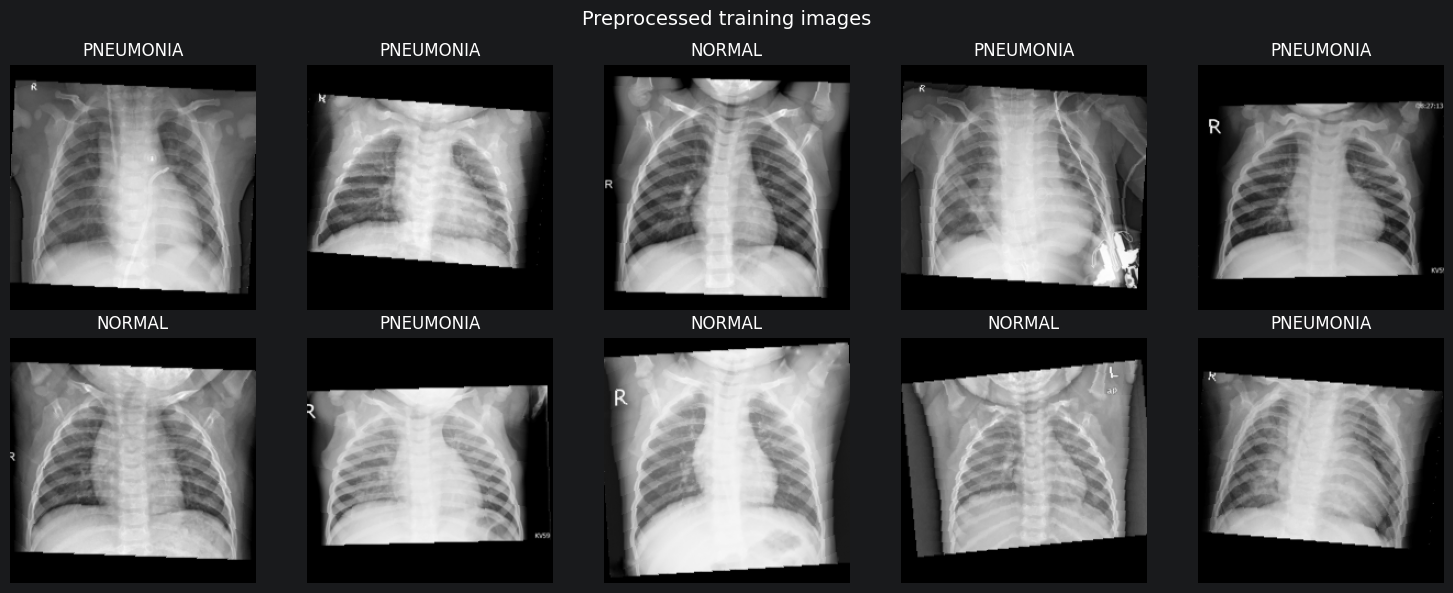

In [17]:
def denormalize_image(tensor):
    mean = torch.tensor([0.5] * NUM_CHANNELS, device=tensor.device).view(NUM_CHANNELS, 1, 1)
    std = torch.tensor([0.5] * NUM_CHANNELS, device=tensor.device).view(NUM_CHANNELS, 1, 1)

    image = (tensor * std + mean).clamp(0, 1)

    if NUM_CHANNELS == 1:
        return image.squeeze(0).cpu().numpy()

    return image.permute(1, 2, 0).cpu().numpy()


print("This cell was slow because next(iter(train_loader)) starts DataLoader worker processes and applies transforms just to preview one batch.")
print("Previewing directly from train_dataset avoids the DataLoader multiprocessing startup overhead.")

preview_indices = torch.multinomial(
    torch.DoubleTensor(sample_weights),
    num_samples=10,
    replacement=True
).tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Preprocessed training images", fontsize=14)

for dataset_index, ax in zip(preview_indices, axes.flat):
    image_tensor, label = train_dataset[dataset_index]
    image = denormalize_image(image_tensor)

    ax.imshow(image, cmap="gray" if NUM_CHANNELS == 1 else None)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

**Model Definition – Custom CNN for Pneumonia Classification**

We use a simple 3-block CNN with batch normalization and dropout to classify chest X-rays as NORMAL (0) or PNEUMONIA (1).

In [18]:
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (confusion_matrix, roc_curve, ConfusionMatrixDisplay)
import copy, time

# Custom CNN with 3 conv blocks, batch norm, and dropout
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: NUM_CHANNELS -> 32 channels
        self.conv = nn.Sequential(
            nn.Conv2d(NUM_CHANNELS, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 32 -> 64 channels
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 64 -> 128 channels
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )
        # After 3x MaxPool2d(2): 224 -> 112 -> 56 -> 28, so feature map is 128*28*28
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)  # 2 classes: NORMAL, PNEUMONIA
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # flatten
        return self.fc(x)

model = PneumoniaCNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

PneumoniaCNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_featur

**Training Setup**

- Loss: CrossEntropyLoss (sampler already handles class imbalance)
- Optimizer: Adam with lr=1e-4
- Scheduler: ReduceLROnPlateau (patience=2, factor=0.5) — automatically reduces the learning rate when validation loss plateaus, preventing overshooting and improving convergence.
- We track loss, accuracy, recall, and precision each epoch for both train and val sets.

In [19]:
# Training hyperparameters
LR = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Storage for metrics per epoch
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_recall": [], "val_recall": [],
    "train_precision": [], "val_precision": [],
}

best_val_loss = float('inf')
best_model_weights = None

**Training Loop**

Each epoch: train on batches, then evaluate on validation set. We save the best model (lowest val loss).

In [20]:
def compute_metrics(all_labels, all_preds):
    """Compute accuracy, recall (sensitivity), and precision from label/pred lists."""
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0       # sensitivity
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    return acc, recall, precision

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # --- Training phase ---
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc, train_recall, train_prec = compute_metrics(train_labels, train_preds)

    # --- Validation phase ---
    model.eval()
    val_running_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc, val_recall, val_prec = compute_metrics(val_labels, val_preds)

    # Step the learning rate scheduler based on validation loss
    scheduler.step(val_loss)

    # Save metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)
    history["train_precision"].append(train_prec)
    history["val_precision"].append(val_prec)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} Rec: {train_recall:.3f} Prec: {train_prec:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} Rec: {val_recall:.3f} Prec: {val_prec:.3f}")

# Restore best model
model.load_state_dict(best_model_weights)
print(f"\nBest val loss: {best_val_loss:.4f} — model restored.")

Epoch 1/15 (9.7s) | Train Loss: 0.4669 Acc: 0.880 Rec: 0.873 Prec: 0.889 | Val Loss: 0.1407 Acc: 0.940 Rec: 0.948 Prec: 0.969
Epoch 2/15 (9.4s) | Train Loss: 0.1771 Acc: 0.936 Rec: 0.936 Prec: 0.935 | Val Loss: 0.1392 Acc: 0.947 Rec: 0.951 Prec: 0.976
Epoch 3/15 (7.5s) | Train Loss: 0.1388 Acc: 0.947 Rec: 0.944 Prec: 0.949 | Val Loss: 0.1372 Acc: 0.954 Rec: 0.946 Prec: 0.990
Epoch 4/15 (6.5s) | Train Loss: 0.1289 Acc: 0.951 Rec: 0.948 Prec: 0.951 | Val Loss: 0.1127 Acc: 0.956 Rec: 0.979 Prec: 0.961
Epoch 5/15 (6.6s) | Train Loss: 0.1035 Acc: 0.964 Rec: 0.966 Prec: 0.962 | Val Loss: 0.1432 Acc: 0.949 Rec: 0.944 Prec: 0.985
Epoch 6/15 (6.6s) | Train Loss: 0.1093 Acc: 0.958 Rec: 0.957 Prec: 0.959 | Val Loss: 0.1049 Acc: 0.957 Rec: 0.974 Prec: 0.967
Epoch 7/15 (6.6s) | Train Loss: 0.0768 Acc: 0.969 Rec: 0.971 Prec: 0.965 | Val Loss: 0.0989 Acc: 0.969 Rec: 0.986 Prec: 0.972
Epoch 8/15 (6.6s) | Train Loss: 0.0667 Acc: 0.972 Rec: 0.973 Prec: 0.971 | Val Loss: 0.1057 Acc: 0.961 Rec: 0.979 Prec

**Training Curves**

Plot loss, accuracy, recall, and precision over epochs for both train and validation.

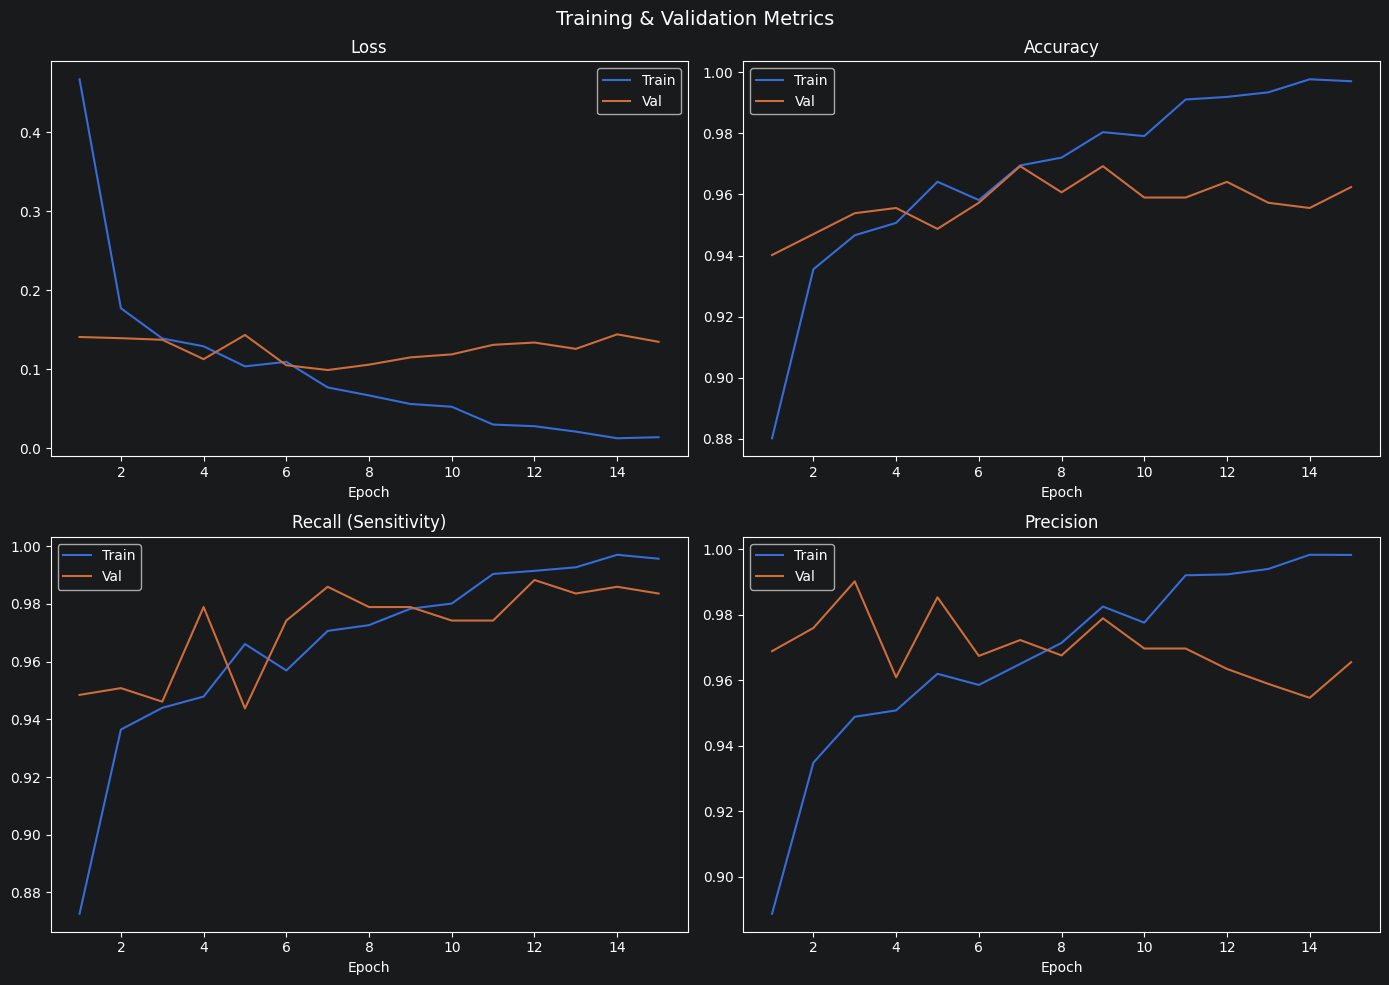

In [21]:
# Plot training curves: loss, accuracy, recall, precision
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, NUM_EPOCHS+1)

# Loss
axes[0, 0].plot(epochs_range, history["train_loss"], label="Train")
axes[0, 0].plot(epochs_range, history["val_loss"], label="Val")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

# Accuracy
axes[0, 1].plot(epochs_range, history["train_acc"], label="Train")
axes[0, 1].plot(epochs_range, history["val_acc"], label="Val")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

# Recall (Sensitivity)
axes[1, 0].plot(epochs_range, history["train_recall"], label="Train")
axes[1, 0].plot(epochs_range, history["val_recall"], label="Val")
axes[1, 0].set_title("Recall (Sensitivity)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()

# Precision
axes[1, 1].plot(epochs_range, history["train_precision"], label="Train")
axes[1, 1].plot(epochs_range, history["val_precision"], label="Val")
axes[1, 1].set_title("Precision")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()

plt.suptitle("Training & Validation Metrics", fontsize=14)
plt.tight_layout()
plt.show()

**Hyperparameter Tuning via Random Search**

Following project guideline section 4 we tune three hyperparameters: **learning rate**, **dropout**, and **weight decay**. We use **AdamW** instead of Adam because AdamW decouples weight decay from the gradient update. All trials also use a **ReduceLROnPlateau** scheduler (factor=0.5, patience=2).

We run **20 trials** in total: trial 1 is the project's default config and trials 2-20 are sampled from:

- `lr` in log-uniform[1e-5, 1e-3]
- `dropout` in uniform[0.2, 0.6]
- `weight_decay` in log-uniform[1e-5, 1e-2]

Each trial trains for the **full `NUM_EPOCHS` (15)** with **early stopping** on validation **Youden's J**. Youden's J is the primary model-selection metric because it balances sensitivity and specificity:

`Youden's J = sensitivity + specificity - 1`

AUC is kept as a secondary, threshold-independent sanity check, but it no longer decides the winning configuration.

Estimated runtime: ~25-35 minutes on an RTX 5070 with the GPU-cached dataset.

In [22]:
import random as py_random
import gc
import pandas as pd

from sklearn.metrics import roc_auc_score as _roc_auc_score

# === Search configuration ===
SEARCH_EPOCHS         = NUM_EPOCHS  # Match the full training length so search ranking is reliable
EARLY_STOP_PATIENCE   = 3           # Stop a trial if val Youden's J has not improved for N epochs
N_RANDOM_TRIALS       = 19          # 19 random samples + 1 default baseline = 20 trials total
SEARCH_SEED           = 42          # Reproducible search

def sample_config(rng):
    """Sample one hyperparameter configuration from the search space."""
    return {
        "lr":           10 ** rng.uniform(-5, -3),
        "dropout":      rng.uniform(0.2, 0.6),
        "weight_decay": 10 ** rng.uniform(-5, -2),
        "batch_size":   rng.choice([16, 32, 64]),
    }

def build_model_with_dropout(p):
    """Fresh PneumoniaCNN with the requested dropout, on the right device."""
    m = PneumoniaCNN()
    for mod in m.modules():
        if isinstance(mod, nn.Dropout):
            mod.p = float(p)
    return m.to(device)

def youden_from_probs(labels, probs):
    """Return the best validation-threshold operating point by Youden's J."""
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    if len(np.unique(labels)) < 2:
        return {"youden_j": 0.0, "threshold": 0.5, "sensitivity": 0.0, "specificity": 0.0}

    fpr, tpr, thresholds = roc_curve(labels, probs)
    j_scores = tpr - fpr
    finite_idx = np.where(np.isfinite(thresholds))[0]
    candidate_idx = finite_idx if len(finite_idx) else np.arange(len(thresholds))
    best_idx = int(candidate_idx[np.argmax(j_scores[candidate_idx])])

    return {
        "youden_j": float(j_scores[best_idx]),
        "threshold": float(thresholds[best_idx]) if np.isfinite(thresholds[best_idx]) else 0.5,
        "sensitivity": float(tpr[best_idx]),
        "specificity": float(1.0 - fpr[best_idx]),
    }

def auc_from_probs(labels, probs):
    """AUC helper with a safe fallback for degenerate label sets."""
    try:
        return float(_roc_auc_score(labels, probs))
    except ValueError:
        return 0.0

def train_one_trial(cfg):
    """Train one random-search trial and return its best validation Youden's J operating point."""
    m    = build_model_with_dropout(cfg["dropout"])
    crit = nn.CrossEntropyLoss()
    opt  = torch.optim.AdamW(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)
    amp_device = device.type if device.type == "cuda" else "cpu"
    scaler = torch.amp.GradScaler(amp_device, enabled=(device.type == "cuda"))

    trial_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], sampler=sampler, **loader_kwargs)

    best_metrics = {
        "youden_j": -1.0,
        "threshold": 0.5,
        "sensitivity": 0.0,
        "specificity": 0.0,
        "auc": 0.0,
        "val_loss": float("inf"),
    }
    no_improve = 0

    for epoch in range(SEARCH_EPOCHS):
        m.train()
        for images, labels in trial_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                loss = crit(m(images), labels)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        m.eval()
        v_labels, v_probs = [], []
        val_loss_accum = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = m(images)
                val_loss_accum += crit(outputs, labels).item() * images.size(0)
                v_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
                v_labels.extend(labels.cpu().numpy())
        val_loss = val_loss_accum / len(val_dataset)
        sched.step(val_loss)

        operating_point = youden_from_probs(v_labels, v_probs)
        current = {
            **operating_point,
            "auc": auc_from_probs(v_labels, v_probs),
            "val_loss": float(val_loss),
        }

        if current["youden_j"] > best_metrics["youden_j"]:
            best_metrics, no_improve = current, 0
        else:
            no_improve += 1
            if no_improve >= EARLY_STOP_PATIENCE:
                break

    del m, opt, sched, scaler, trial_loader
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()
    return best_metrics

search_rng     = py_random.Random(SEARCH_SEED)
DEFAULT_CONFIG = {"lr": 1e-4, "dropout": 0.4, "weight_decay": 0.0, "batch_size": 32}
trial_configs  = [DEFAULT_CONFIG] + [sample_config(search_rng) for _ in range(N_RANDOM_TRIALS)]

print(f"Running {len(trial_configs)} trials x up to {SEARCH_EPOCHS} epochs each...\n")
search_start = time.time()
results = []

for i, cfg in enumerate(trial_configs):
    trial_label = "default" if i == 0 else f"random-{i}"
    print(f"[{i+1:2d}/{len(trial_configs)}] {trial_label:>10s}  "
          f"lr={cfg['lr']:.2e}  dropout={cfg['dropout']:.3f}  wd={cfg['weight_decay']:.1e}  bs={cfg['batch_size']}")
    val_metrics = train_one_trial(cfg)
    results.append({
        "trial": trial_label,
        **cfg,
        "val_youden_j": val_metrics["youden_j"],
        "val_threshold": val_metrics["threshold"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_auc": val_metrics["auc"],
        "val_loss": val_metrics["val_loss"],
    })
    print(f"             -> val Youden's J = {val_metrics['youden_j']:.4f}  "
          f"sens={val_metrics['sensitivity']:.4f}  spec={val_metrics['specificity']:.4f}  "
          f"auc={val_metrics['auc']:.4f}  threshold={val_metrics['threshold']:.4f}")

print(f"\nSearch finished in {(time.time() - search_start) / 60:.1f} minutes.")

Running 20 trials x up to 15 epochs each...

[ 1/20]    default  lr=1.00e-04  dropout=0.400  wd=0.0e+00  bs=32
             -> val Youden's J = 0.9229  sens=0.9672  spec=0.9557  auc=0.9884  threshold=0.5486
[ 2/20]   random-1  lr=1.90e-04  dropout=0.210  wd=6.7e-05  bs=16
             -> val Youden's J = 0.9309  sens=0.9625  spec=0.9684  auc=0.9911  threshold=0.8851
[ 3/20]   random-2  lr=1.90e-05  dropout=0.241  wd=1.7e-03  bs=64
             -> val Youden's J = 0.9103  sens=0.9672  spec=0.9430  auc=0.9878  threshold=0.5352
[ 4/20]   random-3  lr=1.49e-05  dropout=0.369  wd=1.2e-05  bs=16
             -> val Youden's J = 0.9335  sens=0.9461  spec=0.9873  auc=0.9894  threshold=0.5559
[ 5/20]   random-4  lr=2.92e-05  dropout=0.441  wd=4.8e-04  bs=64
             -> val Youden's J = 0.9285  sens=0.9602  spec=0.9684  auc=0.9891  threshold=0.7717
[ 6/20]   random-5  lr=1.99e-04  dropout=0.418  wd=4.6e-05  bs=64
             -> val Youden's J = 0.9299  sens=0.9742  spec=0.9557  auc=0.9928  

**Search results - sorted by validation Youden's J**

The winning configuration is rank 0. We always include the default config so the table directly answers "did random search beat the default?". AUC is reported as secondary context, but the ranking and improvement calculation use validation Youden's J.

In [23]:
# Sort trials by validation Youden's J, with rank 0 = best
results_df = pd.DataFrame(results).sort_values("val_youden_j", ascending=False).reset_index(drop=True)
results_df.index.name = "rank"

display_df = pd.DataFrame({
    "trial":           results_df["trial"],
    "lr":              results_df["lr"].apply(lambda x: f"{x:.2e}"),
    "dropout":         results_df["dropout"].apply(lambda x: f"{x:.3f}"),
    "weight_decay":    results_df["weight_decay"].apply(lambda x: f"{x:.1e}"),
    "batch_size":      results_df["batch_size"].apply(lambda x: str(int(x))),
    "val_youden_j":    results_df["val_youden_j"].apply(lambda x: f"{x:.4f}"),
    "val_sensitivity": results_df["val_sensitivity"].apply(lambda x: f"{x:.4f}"),
    "val_specificity": results_df["val_specificity"].apply(lambda x: f"{x:.4f}"),
    "val_threshold":   results_df["val_threshold"].apply(lambda x: f"{x:.4f}"),
    "val_auc":         results_df["val_auc"].apply(lambda x: f"{x:.4f}"),
})
display_df.index = results_df.index
print("Random Search Results (sorted by validation Youden's J):\n")
print(display_df.to_string())

best_cfg    = results_df.iloc[0]
default_row = results_df[results_df["trial"] == "default"].iloc[0]
delta       = best_cfg["val_youden_j"] - default_row["val_youden_j"]
delta_pct   = (delta / default_row["val_youden_j"]) * 100 if default_row["val_youden_j"] > 0 else 0

print(f"\nBest config:    val Youden's J = {best_cfg['val_youden_j']:.4f}  ({best_cfg['trial']})")
print(f"Default config: val Youden's J = {default_row['val_youden_j']:.4f}")
print(f"Improvement:    {delta:+.4f}  ({delta_pct:+.2f}%)")

Random Search Results (sorted by validation Youden's J):

          trial        lr dropout weight_decay batch_size val_youden_j val_sensitivity val_specificity val_threshold val_auc
rank                                                                                                                        
0     random-18  2.38e-04   0.288      9.4e-05         16       0.9442          0.9696          0.9747        0.6074  0.9908
1      random-3  1.49e-05   0.369      1.2e-05         16       0.9335          0.9461          0.9873        0.5559  0.9894
2     random-13  9.34e-04   0.542      4.0e-03         32       0.9332          0.9649          0.9684        0.3903  0.9905
3     random-16  1.98e-04   0.444      3.3e-05         64       0.9325          0.9578          0.9747        0.7514  0.9909
4     random-17  3.09e-05   0.385      6.5e-05         64       0.9316          0.9696          0.9620        0.4804  0.9927
5      random-9  1.61e-04   0.523      1.5e-03         64       0.9

**Retrain the winning configuration**

We retrain the winner from scratch with **best-model checkpointing on validation Youden's J** and the same **ReduceLROnPlateau** scheduler. This keeps model selection aligned with the primary metric instead of selecting by validation loss.

This gives us **Run 1 tuned**, which we'll later compare against **Run 1 baseline** and (when ready) **Run 2** - the same tuned config trained on the artifact-removed dataset.

In [24]:
# === Retrain the winning configuration for the full NUM_EPOCHS, with best-model checkpointing ===
best_lr           = float(best_cfg["lr"])
best_dropout      = float(best_cfg["dropout"])
best_weight_decay = float(best_cfg["weight_decay"])
best_batch_size   = int(best_cfg["batch_size"])

print(f"Retraining best config for {NUM_EPOCHS} epochs:")
print(f"  lr={best_lr:.2e}  dropout={best_dropout:.3f}  weight_decay={best_weight_decay:.1e}  batch_size={best_batch_size}\n")

tuned_model     = build_model_with_dropout(best_dropout)
tuned_criterion = nn.CrossEntropyLoss()
tuned_optimizer = torch.optim.AdamW(tuned_model.parameters(), lr=best_lr, weight_decay=best_weight_decay)
tuned_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(tuned_optimizer, mode="min", factor=0.5, patience=2)
amp_device = device.type if device.type == "cuda" else "cpu"
tuned_scaler = torch.amp.GradScaler(amp_device, enabled=(device.type == "cuda"))

tuned_train_loader = DataLoader(train_dataset, batch_size=best_batch_size, sampler=sampler, **loader_kwargs)

tuned_history = {k: [] for k in history.keys()}
tuned_best_val_youden_j = -1.0
tuned_best_metrics = None
tuned_best_weights = None

for epoch in range(NUM_EPOCHS):
    start = time.time()

    tuned_model.train()
    running_loss = 0.0
    tr_preds, tr_labels = [], []
    for images, labels in tuned_train_loader:
        images, labels = images.to(device), labels.to(device)
        tuned_optimizer.zero_grad()
        with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
            outputs = tuned_model(images)
            loss = tuned_criterion(outputs, labels)
        tuned_scaler.scale(loss).backward()
        tuned_scaler.step(tuned_optimizer)
        tuned_scaler.update()
        running_loss += loss.item() * images.size(0)
        tr_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        tr_labels.extend(labels.cpu().numpy())
    train_loss = running_loss / len(train_dataset)
    tr_acc, tr_recall, tr_prec = compute_metrics(tr_labels, tr_preds)

    tuned_model.eval()
    val_running_loss = 0.0
    v_preds, v_labels, v_probs = [], [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = tuned_model(images)
            loss = tuned_criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            v_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            v_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())
    val_loss = val_running_loss / len(val_dataset)
    v_acc, v_recall, v_prec = compute_metrics(v_labels, v_preds)
    v_youden = youden_from_probs(v_labels, v_probs)
    v_auc = auc_from_probs(v_labels, v_probs)

    tuned_scheduler.step(val_loss)

    for key, value in [
        ("train_loss", train_loss), ("val_loss", val_loss),
        ("train_acc", tr_acc), ("val_acc", v_acc),
        ("train_recall", tr_recall), ("val_recall", v_recall),
        ("train_precision", tr_prec), ("val_precision", v_prec),
    ]:
        tuned_history[key].append(value)

    if v_youden["youden_j"] > tuned_best_val_youden_j:
        tuned_best_val_youden_j = v_youden["youden_j"]
        tuned_best_metrics = {**v_youden, "auc": v_auc, "val_loss": float(val_loss)}
        tuned_best_weights = copy.deepcopy(tuned_model.state_dict())

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
          f"Val Youden's J: {v_youden['youden_j']:.3f} "
          f"Sens: {v_youden['sensitivity']:.3f} Spec: {v_youden['specificity']:.3f} AUC: {v_auc:.3f}")

tuned_model.load_state_dict(tuned_best_weights)
print(f"\nTuned model restored at best val Youden's J = {tuned_best_val_youden_j:.4f} "
      f"with threshold = {tuned_best_metrics['threshold']:.4f}")

Retraining best config for 15 epochs:
  lr=2.38e-04  dropout=0.288  weight_decay=9.4e-05  batch_size=16

Epoch 1/15 (6.5s) | Train Loss: 0.6730 | Val Loss: 0.1755 Val Youden's J: 0.839 Sens: 0.927 Spec: 0.911 AUC: 0.974
Epoch 2/15 (6.5s) | Train Loss: 0.1709 | Val Loss: 0.1273 Val Youden's J: 0.905 Sens: 0.956 Spec: 0.949 AUC: 0.987
Epoch 3/15 (6.4s) | Train Loss: 0.1541 | Val Loss: 0.1972 Val Youden's J: 0.899 Sens: 0.963 Spec: 0.937 AUC: 0.988
Epoch 4/15 (6.4s) | Train Loss: 0.1319 | Val Loss: 0.1542 Val Youden's J: 0.896 Sens: 0.927 Spec: 0.968 AUC: 0.987
Epoch 5/15 (6.4s) | Train Loss: 0.1288 | Val Loss: 0.1309 Val Youden's J: 0.888 Sens: 0.951 Spec: 0.937 AUC: 0.987
Epoch 6/15 (6.5s) | Train Loss: 0.0812 | Val Loss: 0.1271 Val Youden's J: 0.909 Sens: 0.972 Spec: 0.937 AUC: 0.992
Epoch 7/15 (6.8s) | Train Loss: 0.0656 | Val Loss: 0.1395 Val Youden's J: 0.931 Sens: 0.963 Spec: 0.968 AUC: 0.993
Epoch 8/15 (6.6s) | Train Loss: 0.0582 | Val Loss: 0.1250 Val Youden's J: 0.915 Sens: 0.97

**Final Evaluation on Test Set**

This is the **only** place in the notebook where the held-out test set is used for evaluation. Neither the baseline nor the tuned model has seen these images during training or hyperparameter selection.

For each model, the classification threshold is selected on the **validation set** using Youden's J, then applied once to the held-out test set. The final comparison reports Youden's J as the primary metric, with sensitivity, specificity, and AUC as supporting context.

In [25]:
# === Evaluate baseline and tuned models with validation-selected Youden thresholds ===
# The test set is used only after thresholds have been selected on validation data.

def collect_probs(m, loader):
    """Run a model over a loader and return labels plus PNEUMONIA probabilities."""
    m.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = m(images.to(device))
            all_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_probs)

def threshold_predictions(probs, threshold):
    return (np.asarray(probs) >= threshold).astype(int)

def operating_metrics(labels, probs, threshold):
    """Metrics at a fixed threshold, with AUC retained as secondary context."""
    preds = threshold_predictions(probs, threshold)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "threshold": float(threshold),
        "youden_j": float(sensitivity + specificity - 1.0),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "auc": auc_from_probs(labels, probs),
        "cm": np.array([[tn, fp], [fn, tp]]),
        "preds": preds,
    }

val_labels_base, val_probs_base = collect_probs(model, val_loader)
base_val_op = youden_from_probs(val_labels_base, val_probs_base)

val_labels_tuned, val_probs_tuned = collect_probs(tuned_model, val_loader)
tuned_val_op = youden_from_probs(val_labels_tuned, val_probs_tuned)

test_labels, baseline_probs = collect_probs(model, test_loader)
_, tuned_probs = collect_probs(tuned_model, test_loader)

baseline_test = operating_metrics(test_labels, baseline_probs, base_val_op["threshold"])
tuned_test = operating_metrics(test_labels, tuned_probs, tuned_val_op["threshold"])

summary_df = pd.DataFrame([
    {
        "model": "baseline",
        "val_threshold": baseline_test["threshold"],
        "test_youden_j": baseline_test["youden_j"],
        "test_sensitivity": baseline_test["sensitivity"],
        "test_specificity": baseline_test["specificity"],
        "test_auc": baseline_test["auc"],
    },
    {
        "model": "tuned",
        "val_threshold": tuned_test["threshold"],
        "test_youden_j": tuned_test["youden_j"],
        "test_sensitivity": tuned_test["sensitivity"],
        "test_specificity": tuned_test["specificity"],
        "test_auc": tuned_test["auc"],
    },
])

print("Final Test Metrics (threshold selected by validation Youden's J):\n")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nPrimary metric delta (tuned - baseline): {tuned_test['youden_j'] - baseline_test['youden_j']:+.4f}")

Final Test Metrics (threshold selected by validation Youden's J):

   model  val_threshold  test_youden_j  test_sensitivity  test_specificity  test_auc
baseline         0.7775         0.8920            0.9486            0.9434    0.9865
   tuned         0.3869         0.8936            0.9439            0.9497    0.9903

Primary metric delta (tuned - baseline): +0.0016


**Confusion Matrices - Validation-Selected Youden Thresholds**

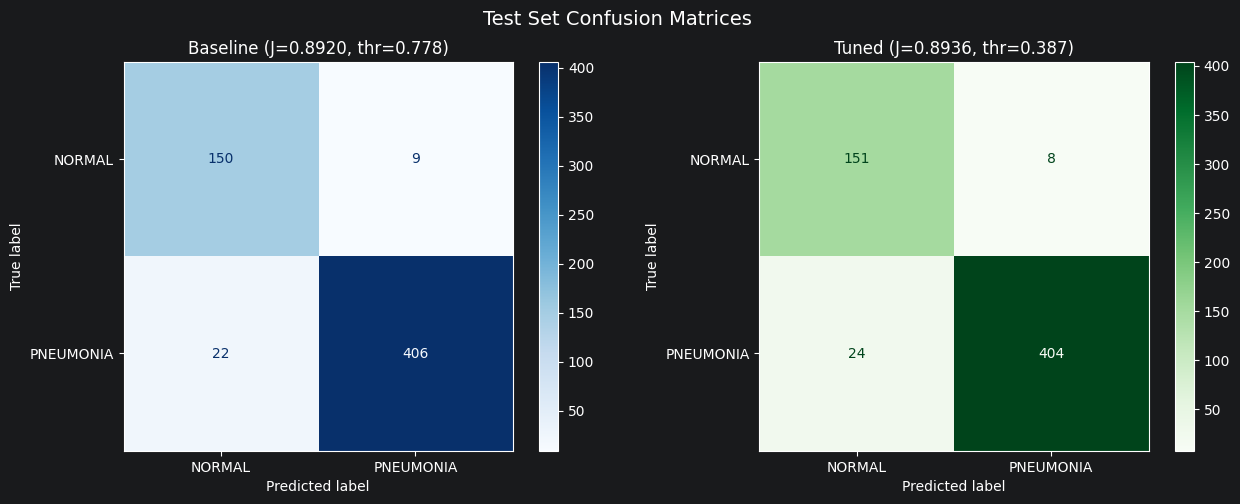

In [26]:
# Side-by-side confusion matrices at the validation-selected Youden thresholds.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix=baseline_test["cm"], display_labels=classes).plot(ax=ax1, cmap="Blues")
ax1.set_title(f"Baseline (J={baseline_test['youden_j']:.4f}, thr={baseline_test['threshold']:.3f})")

ConfusionMatrixDisplay(confusion_matrix=tuned_test["cm"], display_labels=classes).plot(ax=ax2, cmap="Greens")
ax2.set_title(f"Tuned (J={tuned_test['youden_j']:.4f}, thr={tuned_test['threshold']:.3f})")

plt.suptitle("Test Set Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

**ROC Curves - Secondary Context**

The ROC curve is retained as supporting context because it shows ranking quality across thresholds. The primary comparison still uses test Youden's J at thresholds selected on the validation set.

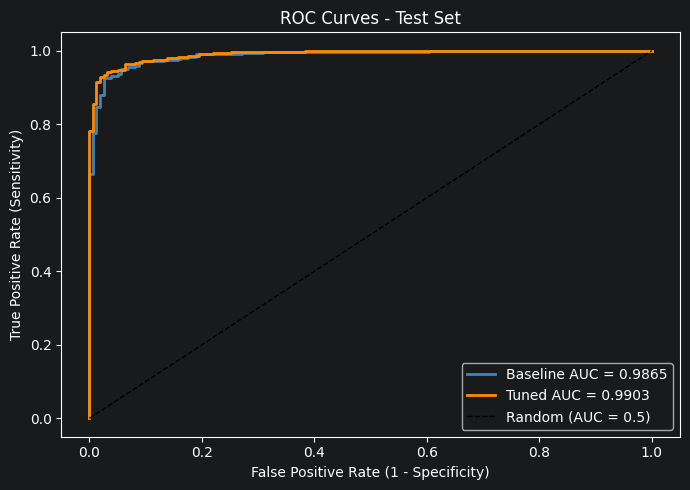

In [27]:
# ROC curves for both models. AUC is secondary context, not the model-selection metric.
fpr_base, tpr_base, _ = roc_curve(test_labels, baseline_probs)
fpr_tuned, tpr_tuned, _ = roc_curve(test_labels, tuned_probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_base, tpr_base, label=f"Baseline AUC = {baseline_test['auc']:.4f}", color="steelblue", lw=2)
ax.plot(fpr_tuned, tpr_tuned, label=f"Tuned AUC = {tuned_test['auc']:.4f}", color="darkorange", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curves - Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Validation Threshold Details**

This cell prints the validation operating points that selected the final thresholds. Keeping this separate makes the threshold choice auditable without adding noisy classification reports.

In [28]:
threshold_df = pd.DataFrame([
    {
        "model": "baseline",
        "val_threshold": base_val_op["threshold"],
        "val_youden_j": base_val_op["youden_j"],
        "val_sensitivity": base_val_op["sensitivity"],
        "val_specificity": base_val_op["specificity"],
        "val_auc": auc_from_probs(val_labels_base, val_probs_base),
    },
    {
        "model": "tuned",
        "val_threshold": tuned_val_op["threshold"],
        "val_youden_j": tuned_val_op["youden_j"],
        "val_sensitivity": tuned_val_op["sensitivity"],
        "val_specificity": tuned_val_op["specificity"],
        "val_auc": auc_from_probs(val_labels_tuned, val_probs_tuned),
    },
])

print("Validation Operating Points (selected by Youden's J):\n")
print(threshold_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Validation Operating Points (selected by Youden's J):

   model  val_threshold  val_youden_j  val_sensitivity  val_specificity  val_auc
baseline         0.7775        0.9332           0.9649           0.9684   0.9916
   tuned         0.3869        0.9309           0.9625           0.9684   0.9928


**Locked Two-Dataset Experiment**

This section trains one fresh model on the original dataset and one fresh model on the cleaned dataset. Hyperparameters, architecture, split membership, preprocessing, sampler logic, and threshold-selection method are locked so the only experimental difference is the dataset path.


In [29]:
import copy
import time
import pandas as pd
from sklearn.metrics import roc_auc_score


def apply_dropout(model_to_update, dropout: float):
    """Set every Dropout layer to the locked experiment dropout value."""
    for module in model_to_update.modules():
        if isinstance(module, nn.Dropout):
            module.p = float(dropout)


def build_locked_model(training: TrainingConfig):
    """Create a fresh CNN using the locked training configuration."""
    model_to_train = PneumoniaCNN().to(device)
    apply_dropout(model_to_train, training.dropout)
    return model_to_train


def auc_from_probs_safe(labels, probs):
    try:
        return float(roc_auc_score(labels, probs))
    except ValueError:
        return 0.0


def youden_from_probs_safe(labels, probs):
    """Select a threshold from validation probabilities using Youden's J."""
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    if len(np.unique(labels)) < 2:
        return {"youden_j": 0.0, "threshold": 0.5, "sensitivity": 0.0, "specificity": 0.0}

    fpr, tpr, thresholds = roc_curve(labels, probs)
    j_scores = tpr - fpr
    finite_idx = np.where(np.isfinite(thresholds))[0]
    candidate_idx = finite_idx if len(finite_idx) else np.arange(len(thresholds))
    best_idx = int(candidate_idx[np.argmax(j_scores[candidate_idx])])

    return {
        "youden_j": float(j_scores[best_idx]),
        "threshold": float(thresholds[best_idx]) if np.isfinite(thresholds[best_idx]) else 0.5,
        "sensitivity": float(tpr[best_idx]),
        "specificity": float(1.0 - fpr[best_idx]),
    }


def collect_probs_for_loader(model_to_eval, loader):
    """Return labels and PNEUMONIA probabilities for one model/loader pair."""
    model_to_eval.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model_to_eval(images.to(device))
            all_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_probs)


def metrics_at_threshold(labels, probs, threshold):
    preds = (np.asarray(probs) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0
    return {
        "threshold": float(threshold),
        "youden_j": float(sensitivity + specificity - 1.0),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "accuracy": float(accuracy),
        "auc": auc_from_probs_safe(labels, probs),
        "cm": np.array([[tn, fp], [fn, tp]]),
        "preds": preds,
    }


def compute_metrics_for_run(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    return accuracy, recall, precision


def train_locked_experiment(bundle: DataBundle, training: TrainingConfig = LOCKED_TRAINING):
    """Train one isolated model and evaluate it with a validation-selected threshold."""
    set_all_seeds(bundle.config.seed)
    run_model = build_locked_model(training)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(run_model.parameters(), lr=training.lr, weight_decay=training.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    amp_device = device.type if device.type == "cuda" else "cpu"
    scaler = torch.amp.GradScaler(amp_device, enabled=(device.type == "cuda"))

    run_history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_recall": [], "val_recall": [],
        "train_precision": [], "val_precision": [],
    }
    best_val_youden_j = -1.0
    best_weights = None
    best_val_metrics = None

    print(f"\n=== Training {bundle.config.name} on {bundle.config.base_dir} ===")
    for epoch in range(training.num_epochs):
        start = time.time()
        run_model.train()
        running_loss = 0.0
        train_preds, train_labels = [], []

        for images, labels in bundle.train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                outputs = run_model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(bundle.train_dataset)
        train_acc, train_recall, train_prec = compute_metrics_for_run(train_labels, train_preds)

        run_model.eval()
        val_running_loss = 0.0
        val_preds, val_labels, val_probs = [], [], []
        with torch.no_grad():
            for images, labels in bundle.val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = run_model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                val_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(bundle.val_dataset)
        val_acc, val_recall, val_prec = compute_metrics_for_run(val_labels, val_preds)
        val_op = youden_from_probs_safe(val_labels, val_probs)
        val_auc = auc_from_probs_safe(val_labels, val_probs)
        scheduler.step(val_loss)

        for key, value in [
            ("train_loss", train_loss), ("val_loss", val_loss),
            ("train_acc", train_acc), ("val_acc", val_acc),
            ("train_recall", train_recall), ("val_recall", val_recall),
            ("train_precision", train_prec), ("val_precision", val_prec),
        ]:
            run_history[key].append(value)

        if val_op["youden_j"] > best_val_youden_j:
            best_val_youden_j = val_op["youden_j"]
            best_weights = copy.deepcopy(run_model.state_dict())
            best_val_metrics = {**val_op, "auc": val_auc, "val_loss": float(val_loss)}

        elapsed = time.time() - start
        print(
            f"{bundle.config.name} epoch {epoch + 1}/{training.num_epochs} ({elapsed:.1f}s) | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"val_J={val_op['youden_j']:.4f} sens={val_op['sensitivity']:.4f} "
            f"spec={val_op['specificity']:.4f} auc={val_auc:.4f}"
        )

    run_model.load_state_dict(best_weights)
    val_labels_final, val_probs_final = collect_probs_for_loader(run_model, bundle.val_loader)
    val_op_final = youden_from_probs_safe(val_labels_final, val_probs_final)
    test_labels_final, test_probs_final = collect_probs_for_loader(run_model, bundle.test_loader)
    test_metrics = metrics_at_threshold(test_labels_final, test_probs_final, val_op_final["threshold"])

    return ExperimentResult(
        config=bundle.config,
        training=training,
        model=run_model,
        history=run_history,
        val_threshold=val_op_final["threshold"],
        val_metrics={**val_op_final, "auc": auc_from_probs_safe(val_labels_final, val_probs_final)},
        test_metrics=test_metrics,
    )


In [30]:
# Build independent data/loaders for each dataset variant.
experiment_bundles = {
    name: build_data_bundle(config, splits_data, LOCKED_TRAINING, cache_device=device)
    for name, config in RUN_CONFIGS.items()
}

# Train a fresh model for each dataset using exactly the same locked hyperparameters.
experiment_results = {
    name: train_locked_experiment(bundle, LOCKED_TRAINING)
    for name, bundle in experiment_bundles.items()
}

comparison_df = pd.DataFrame([
    {
        "dataset": name,
        "val_threshold": result.val_threshold,
        "test_youden_j": result.test_metrics["youden_j"],
        "test_sensitivity": result.test_metrics["sensitivity"],
        "test_specificity": result.test_metrics["specificity"],
        "test_accuracy": result.test_metrics["accuracy"],
        "test_auc": result.test_metrics["auc"],
    }
    for name, result in experiment_results.items()
])

if {"original", "cleaned"}.issubset(experiment_results):
    original = experiment_results["original"].test_metrics
    cleaned = experiment_results["cleaned"].test_metrics
    comparison_df = pd.concat([
        comparison_df,
        pd.DataFrame([{
            "dataset": "cleaned - original",
            "val_threshold": np.nan,
            "test_youden_j": cleaned["youden_j"] - original["youden_j"],
            "test_sensitivity": cleaned["sensitivity"] - original["sensitivity"],
            "test_specificity": cleaned["specificity"] - original["specificity"],
            "test_accuracy": cleaned["accuracy"] - original["accuracy"],
            "test_auc": cleaned["auc"] - original["auc"],
        }])
    ], ignore_index=True)

print("Locked Two-Dataset Test Comparison:\n")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Caching 4684 images to cuda … done.
Caching 585 images to cuda … done.
Caching 587 images to cuda … done.
Caching 4684 images to cuda … done.
Caching 585 images to cuda … done.
Caching 587 images to cuda … done.

=== Training original on ./chest_xray/chest_xray ===
original epoch 1/15 (7.0s) | train_loss=0.4751 val_loss=0.1501 val_J=0.8805 sens=0.9438 spec=0.9367 auc=0.9831
original epoch 2/15 (6.9s) | train_loss=0.1759 val_loss=0.1369 val_J=0.8953 sens=0.9649 spec=0.9304 auc=0.9861
original epoch 3/15 (6.9s) | train_loss=0.1479 val_loss=0.1347 val_J=0.8777 sens=0.9789 spec=0.8987 auc=0.9852
original epoch 4/15 (5.1s) | train_loss=0.1151 val_loss=0.1303 val_J=0.8885 sens=0.9391 spec=0.9494 auc=0.9859
original epoch 5/15 (5.0s) | train_loss=0.0976 val_loss=0.2999 val_J=0.8793 sens=0.9742 spec=0.9051 auc=0.9868
original epoch 6/15 (4.9s) | train_loss=0.0933 val_loss=0.1265 val_J=0.8808 sens=0.9251 spec=0.9557 auc=0.9865
original epoch 7/15 (4.9s) | train_loss=0.0778 val_loss=0.1314 val_J

In [31]:
import joblib

for name, result in experiment_results.items():
    path = f"CNN_{name}.pkl"
    joblib.dump(result.model, path)
    print(f"Saved {name} model to {path}")


Saved original model to CNN_original.pkl
Saved cleaned model to CNN_cleaned.pkl


**Restore chart in report**

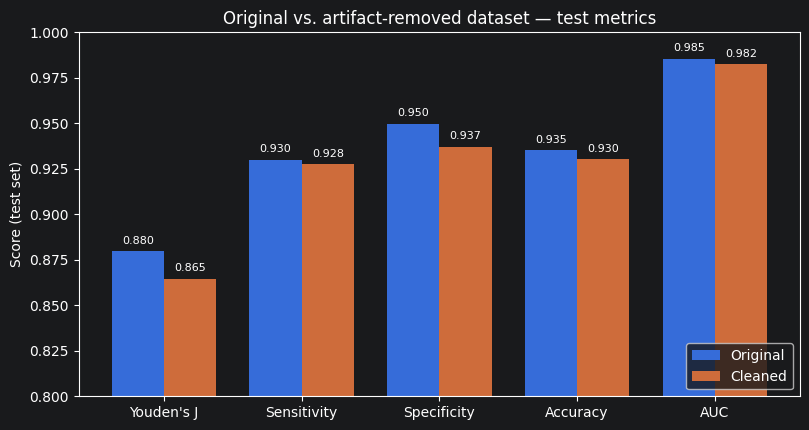

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data
cleaned = {
    "sensitivity": 0.9276,
    "specificity": 0.9371,
    "accuracy": 0.9302,
    "auc": 0.9824,
}
cleaned["youden_j"] = cleaned["sensitivity"] + cleaned["specificity"] - 1.0

original = {
    "sensitivity": 0.9299,
    "specificity": 0.9497,
    "accuracy": 0.9353,
    "auc": 0.9854,
}
original["youden_j"] = original["sensitivity"] + original["specificity"] - 1.0

# Order of metrics
metrics = ["youden_j", "sensitivity", "specificity", "accuracy", "auc"]
labels = ["Youden's J", "Sensitivity", "Specificity", "Accuracy", "AUC"]

orig_vals = [original[m] for m in metrics]
clean_vals = [cleaned[m] for m in metrics]

# Plot
x = np.arange(len(metrics))
width = 0.38

fig, ax = plt.subplots(figsize=(8.2, 4.4))


bars1 = ax.bar(
    x - width/2,
    orig_vals,
    width,
    label="Original"
)

bars2 = ax.bar(
    x + width/2,
    clean_vals,
    width,
    label="Cleaned"
)

# Labels on top of bars
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.003,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_title("Original vs. artifact-removed dataset — test metrics")
ax.set_ylabel("Score (test set)")
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0.80, 1.00)

ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()